<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°05





**Objetivo**: Explorar y visualizar datos de Netflix usando **matplotlib** y **seaborn/plotly**, aprendiendo a elegir gráficos adecuados para distintos tipos de variables y preguntas de análisis.



**Dataset**:

Trabajaremos con el archivo `netflix_titles.csv`, que contiene información sobre los títulos disponibles en la plataforma Netflix hasta el año 2021.

| Variable       | Clase     | Descripción                                                                 |
|----------------|-----------|------------------------------------------------------------------------------|
| show_id        | caracter  | Identificador único del título en el catálogo de Netflix.                   |
| type           | caracter  | Tipo de contenido: 'Movie' o 'TV Show'.                                     |
| title          | caracter  | Título del contenido.                                                       |
| director       | caracter  | Nombre del director (puede ser nulo).                                       |
| cast           | caracter  | Lista de actores principales (puede ser nulo).                              |
| country        | caracter  | País o países donde se produjo el contenido.                                |
| date_added     | fecha     | Fecha en la que el título fue agregado al catálogo de Netflix.              |
| release_year   | entero    | Año de lanzamiento original del título.                                     |
| rating         | caracter  | Clasificación por edad (por ejemplo: 'PG-13', 'TV-MA').                      |
| duration       | caracter  | Duración del contenido (minutos o número de temporadas para series).        |
| listed_in      | caracter  | Categorías o géneros en los que está clasificado el contenido.              |
| description    | caracter  | Breve sinopsis del contenido.                                               |




In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [2]:
# Cargar datos
df = pd.read_csv('https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 📊 Parte 1: Exploración visual básica

1. **Distribución de tipos de contenido**

   * Realiza un gráfico de barras mostrando la cantidad de películas vs series (`type`).
   * Pregunta guía: ¿Cuál es el tipo de contenido predominante en Netflix? ¿Qué implicancias podría tener para los usuarios?

2. **Histograma de años de lanzamiento**

   * Muestra cómo se distribuyen los títulos según su `release_year`.
   * Pregunta guía: ¿Hay más contenido reciente o antiguo? ¿Notas algún patrón en décadas específicas?

3. **Proporción de clasificaciones por edad (`rating`)**

   * Haz un gráfico circular o de barras.
   * Pregunta guía: ¿Qué clasificación es más común? ¿Crees que Netflix está más enfocado en público adulto, familiar o infantil?



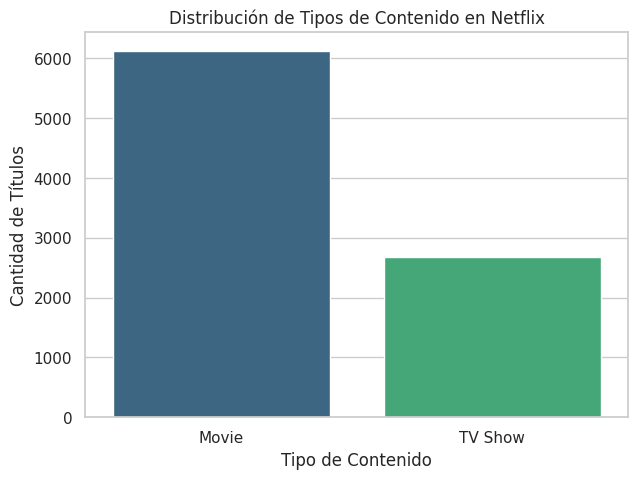

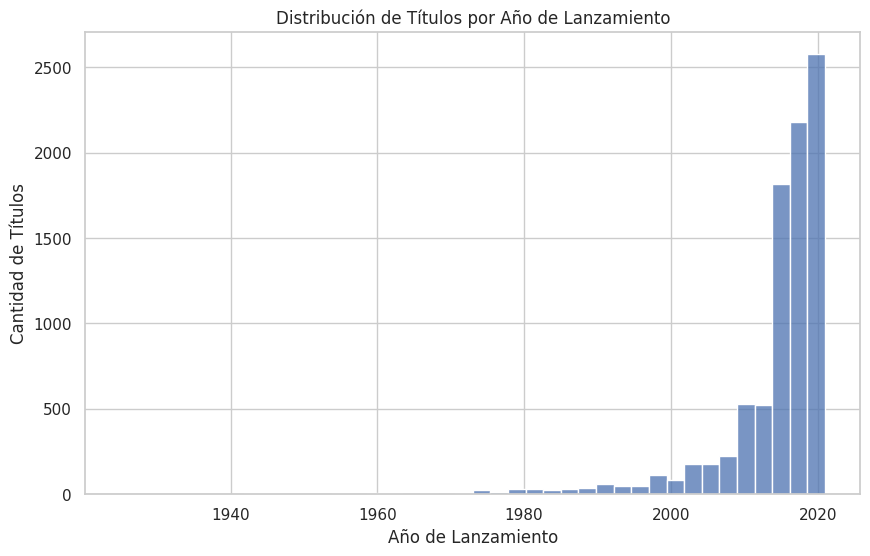

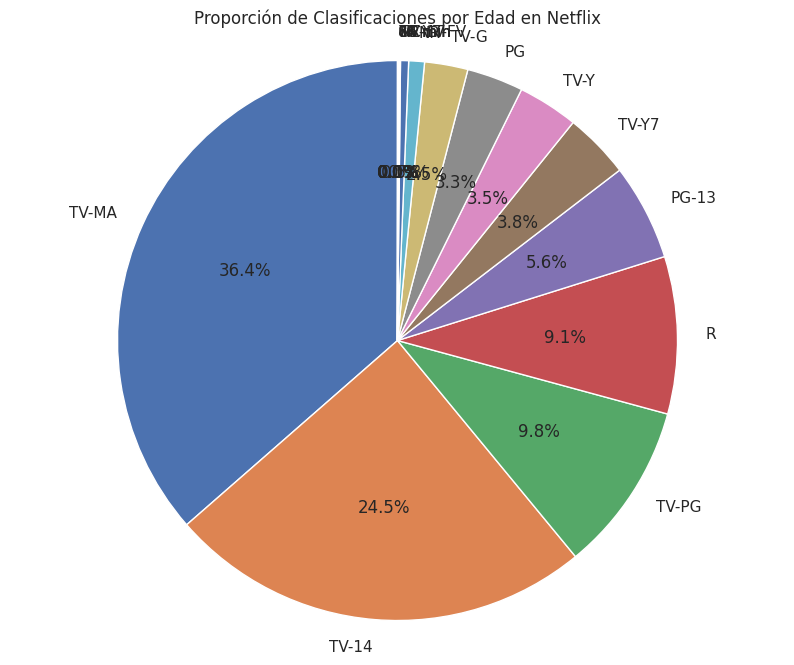

In [7]:
import matplotlib.pyplot as plt

# 1. Distribución de tipos de contenido
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='type', hue='type', palette='viridis', legend=False)
plt.title('Distribución de Tipos de Contenido en Netflix')
plt.xlabel('Tipo de Contenido')
plt.ylabel('Cantidad de Títulos')
plt.show()

# ¿Cuál es el tipo de contenido predominante en Netflix? ¿Qué implicancias podría tener para los usuarios?
# Respuesta: Las películas son el tipo de contenido predominante. Esto podría implicar que Netflix
# es percibido principalmente como una plataforma de películas, aunque también ofrece una gran variedad de series.

# 2. Histograma de años de lanzamiento
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='release_year', bins=40, kde=False)
plt.title('Distribución de Títulos por Año de Lanzamiento')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Cantidad de Títulos')
plt.show()

# ¿Hay más contenido reciente o antiguo? ¿Notas algún patrón en décadas específicas?
# Respuesta: Hay una clara tendencia hacia contenido más reciente, con un pico significativo en los últimos años.
# Se observa un aumento constante en la producción de títulos a partir de la década de 2000,
# intensificándose en la década de 2010.

# 3. Proporción de clasificaciones por edad (rating)
# Limpiar datos: eliminar filas con 'rating' nulo para el gráfico circular
rating_counts = df['rating'].dropna().value_counts()

plt.figure(figsize=(10, 8))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Proporción de Clasificaciones por Edad en Netflix')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

# ¿Qué clasificación es más común? ¿Crees que Netflix está más enfocado en público adulto, familiar o infantil?
# Respuesta: Las clasificaciones 'TV-MA' (para audiencias maduras) y 'TV-14' (para mayores de 14 años)
# son las más comunes, seguidas por 'TV-PG'. Esto sugiere que Netflix tiene un enfoque significativo en
# el público adolescente y adulto, aunque también ofrece contenido para audiencias más jóvenes.



## 🎨 Parte 2: Tendencias y evolución en el tiempo

4. **Número de títulos agregados por año**

   * Usa `date_added` (convertido a fecha) y grafica una serie temporal.
   * Pregunta guía: ¿Cuándo creció más el catálogo de Netflix? ¿Qué relación podría tener con la expansión internacional de la plataforma?

5. **Heatmap de lanzamientos por año y mes**

   * Construye un mapa de calor con `year_added` y `month_added`.
   * Pregunta guía: ¿Hay meses con más estrenos que otros? ¿Qué conclusiones puedes sacar sobre la estacionalidad de lanzamientos?

6. **Duración de películas por género**

   * Extrae la duración en minutos y crea un boxplot agrupado por género principal.
   * Pregunta guía: ¿Qué géneros suelen durar más? ¿Qué podrías decir sobre la variabilidad dentro de un mismo género?


<>:52: SyntaxWarning: invalid escape sequence '\d'
<>:52: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_9357/3386876236.py:52: SyntaxWarning: invalid escape sequence '\d'
  movies_df['duration_minutes'] = movies_df['duration'].str.extract('(\d+)').astype(float)


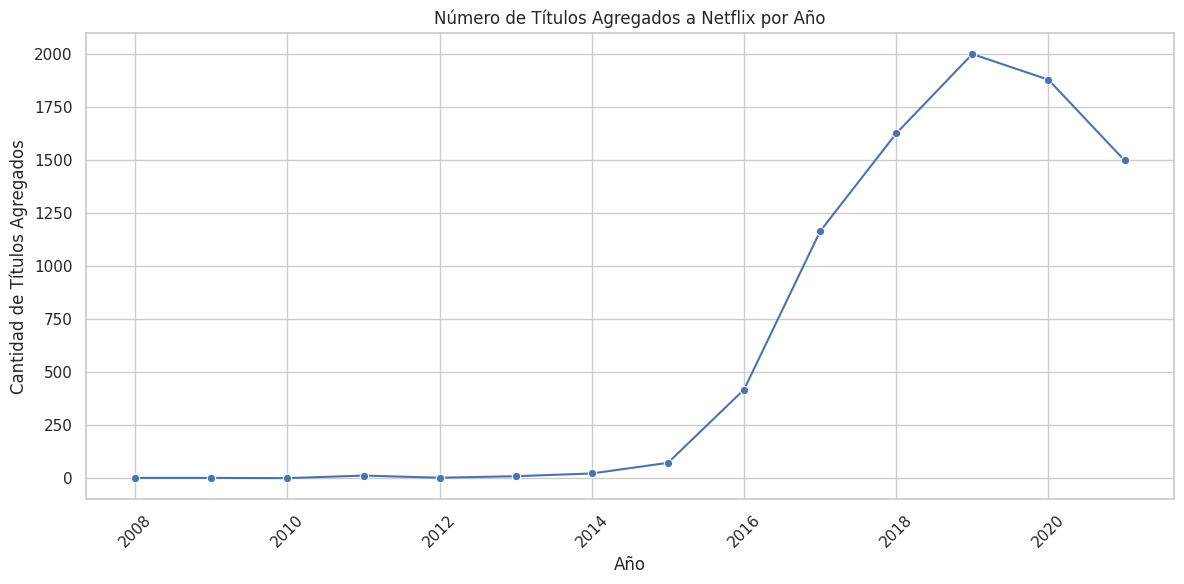

/tmp/ipykernel_9357/3386876236.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  release_heatmap_data = df.groupby(['year_added', 'month_added']).size().unstack(fill_value=0)


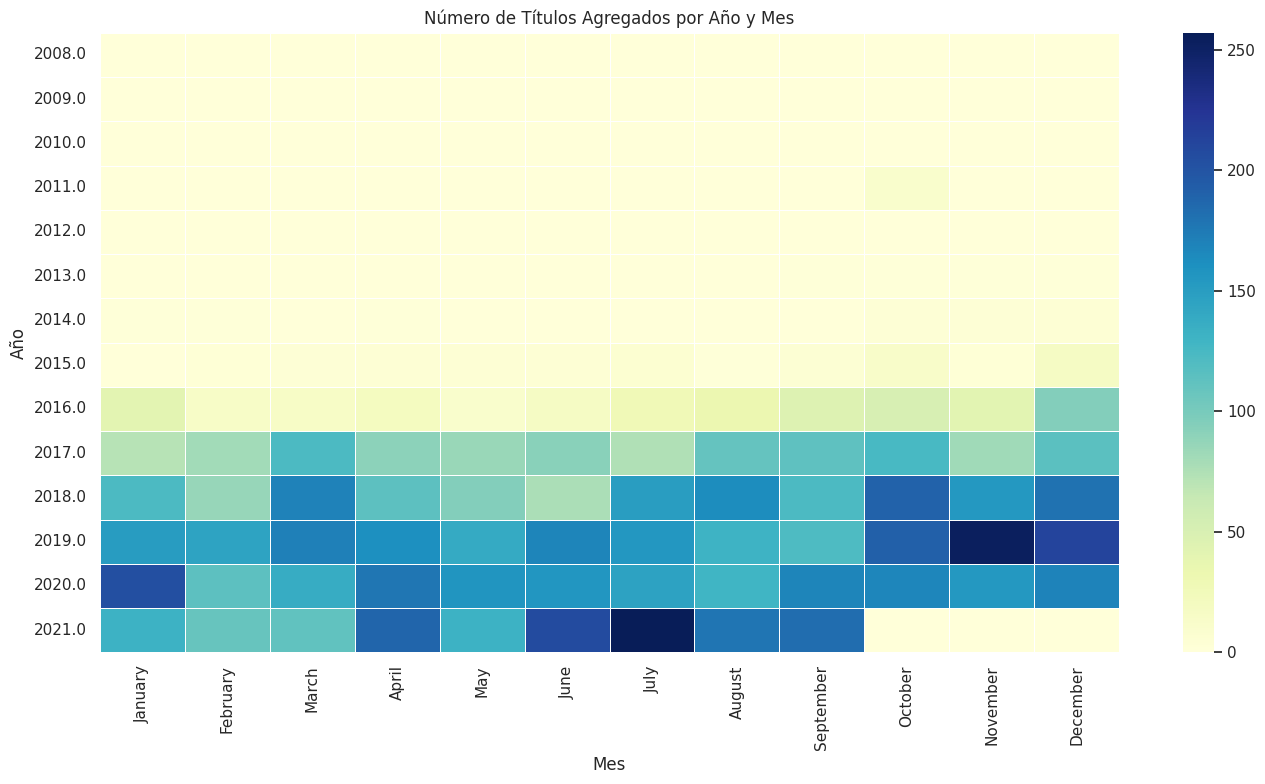

/tmp/ipykernel_9357/3386876236.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=movies_top_genres_df, x='duration_minutes', y='main_genre', palette='viridis')


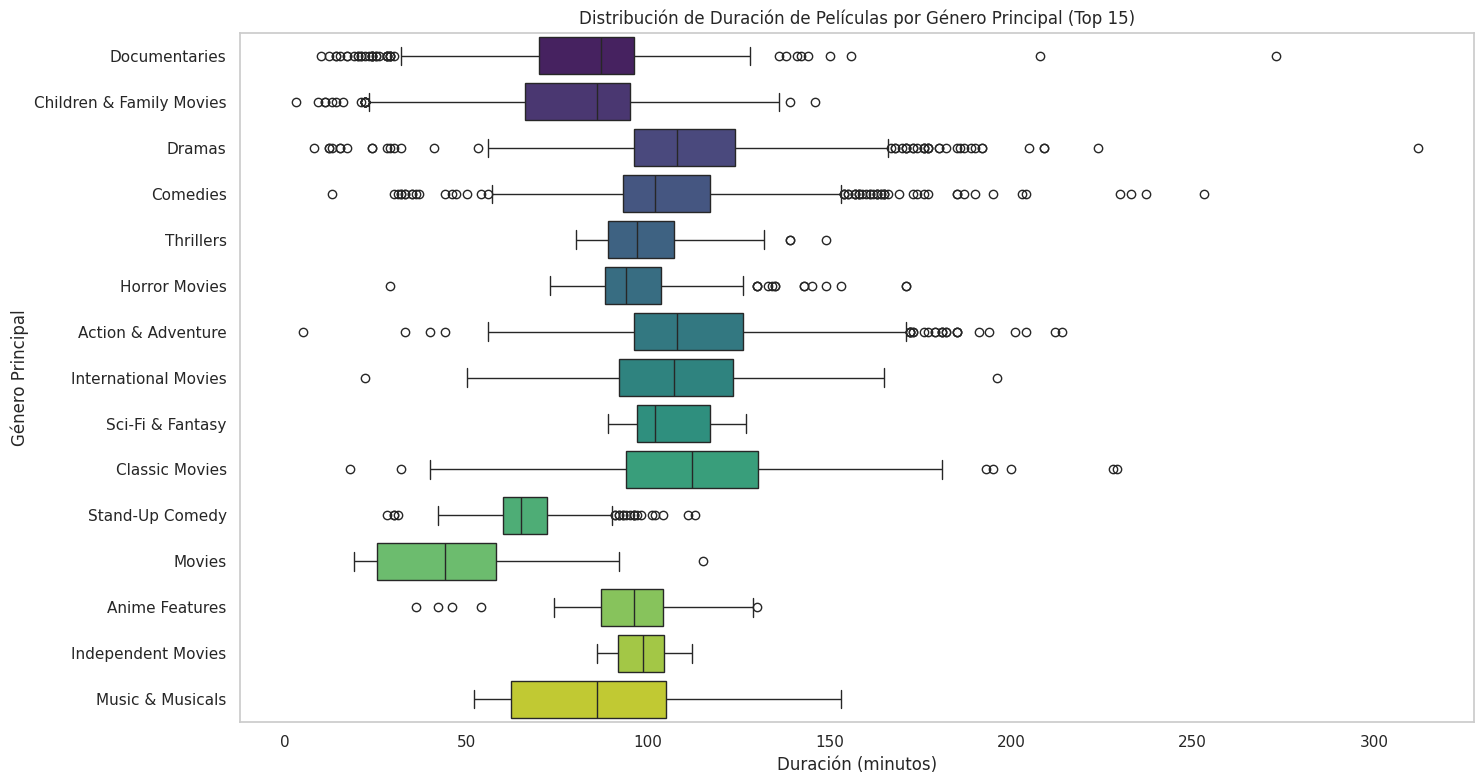

In [8]:
import numpy as np

# Convert 'date_added' to datetime objects and extract year and month
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# 4. Número de títulos agregados por año
titles_per_year = df.dropna(subset=['year_added'])['year_added'].astype(int).value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=titles_per_year.index, y=titles_per_year.values, marker='o')
plt.title('Número de Títulos Agregados a Netflix por Año')
plt.xlabel('Año')
plt.ylabel('Cantidad de Títulos Agregados')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ¿Cuándo creció más el catálogo de Netflix? ¿Qué relación podría tener con la expansión internacional de la plataforma?
# Respuesta: El catálogo de Netflix experimentó un crecimiento significativo, especialmente a partir de 2016-2017,
# con un pico notable en 2019. Este crecimiento puede estar directamente relacionado con la expansión
# global de la plataforma, la inversión en contenido original y la adquisición de licencias para mercados internacionales.

# 5. Heatmap de lanzamientos por año y mes
# Asegurarse de que month_added es una categoría ordenada para el heatmap
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['month_added'] = pd.Categorical(df['month_added'], categories=month_order, ordered=True)

# Crear tabla pivote para el heatmap
release_heatmap_data = df.groupby(['year_added', 'month_added']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(release_heatmap_data, cmap='YlGnBu', fmt='d', linewidths=.5)
plt.title('Número de Títulos Agregados por Año y Mes')
plt.xlabel('Mes')
plt.ylabel('Año')
plt.tight_layout()
plt.show()

# ¿Hay meses con más estrenos que otros? ¿Qué conclusiones puedes sacar sobre la estacionalidad de lanzamientos?
# Respuesta: Se observa una mayor concentración de estrenos y adiciones de contenido hacia finales de año (octubre, noviembre, diciembre)
# y a principios de año (enero). Esto podría indicar una estrategia de lanzamientos para captar audiencias durante
# períodos vacacionales o de menor actividad, así como al inicio de nuevos ciclos de consumo de contenido.

# 6. Duración de películas por género
# Filtrar solo películas
movies_df = df[df['type'] == 'Movie'].copy()

# Extraer duración en minutos
movies_df['duration_minutes'] = movies_df['duration'].str.extract('(\d+)').astype(float)

# Manejar múltiples géneros: tomar el primer género de la lista
movies_df['main_genre'] = movies_df['listed_in'].apply(lambda x: x.split(',')[0].strip() if pd.notna(x) else np.nan)

# Eliminar filas con duración o género nulo
movies_df.dropna(subset=['duration_minutes', 'main_genre'], inplace=True)

# Seleccionar los top N géneros para mejor visualización
top_genres = movies_df['main_genre'].value_counts().nlargest(15).index
movies_top_genres_df = movies_df[movies_df['main_genre'].isin(top_genres)]

plt.figure(figsize=(15, 8))
sns.boxplot(data=movies_top_genres_df, x='duration_minutes', y='main_genre', palette='viridis')
plt.title('Distribución de Duración de Películas por Género Principal (Top 15)')
plt.xlabel('Duración (minutos)')
plt.ylabel('Género Principal')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

# ¿Qué géneros suelen durar más? ¿Qué podrías decir sobre la variabilidad dentro de un mismo género?
# Respuesta: Géneros como 'Documentaries', 'Dramas' e 'International Movies' parecen tener una duración media
# ligeramente mayor. La variabilidad dentro de un mismo género es considerable, lo que indica que, si bien
# existen tendencias, no hay una regla estricta para la duración de las películas dentro de una categoría.



## 🔥 Parte 3: Comparaciones y relaciones

7. **Top 10 países con más producciones**

   * Usa un gráfico de barras para mostrar los países más frecuentes en la columna `country`.
   * Pregunta guía: ¿Qué países dominan el catálogo? ¿Sorprende la distribución o es esperada?

8. **Películas vs Series según género**

   * Realiza un gráfico de barras apiladas para mostrar la cantidad de títulos por género, separando `Movie` y `TV Show`.
   * Pregunta guía: ¿Existen géneros más asociados a películas o a series?

9. **Relación entre duración y año de lanzamiento**

   * Haz un gráfico de dispersión (scatterplot) con `release_year` en el eje X y `duration` (en minutos) en el eje Y.
   * Pregunta guía: ¿Han cambiado los estándares de duración de las películas con el tiempo? ¿Se ven outliers interesantes?



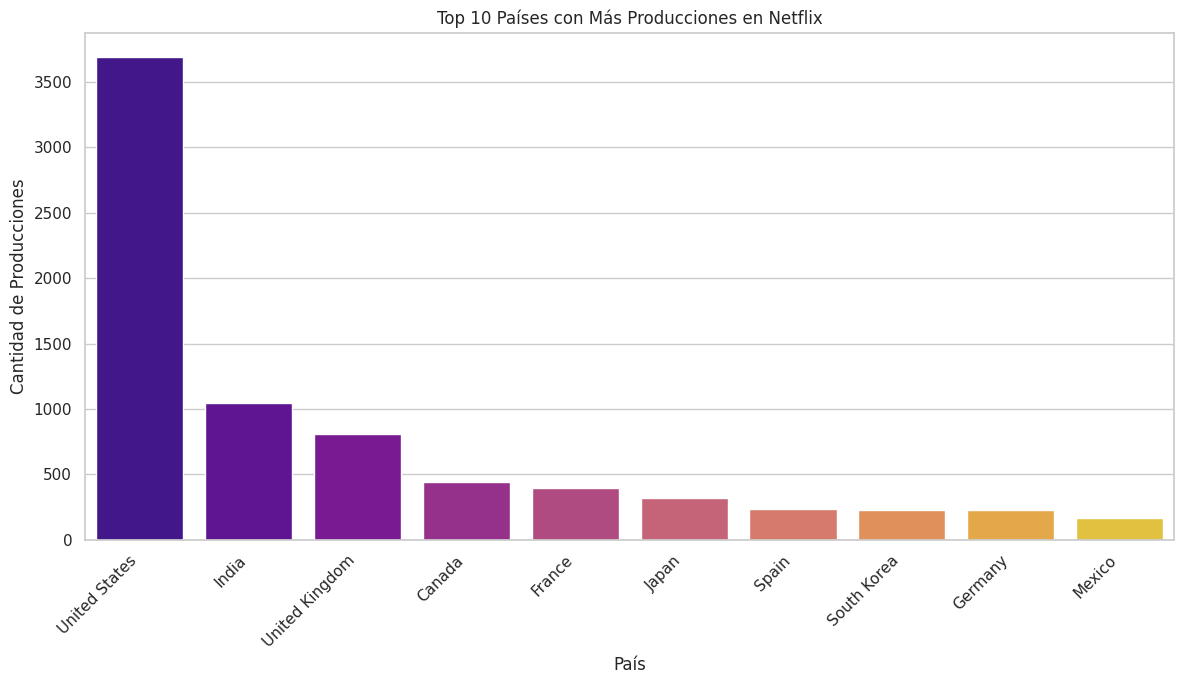

<Figure size 1400x800 with 0 Axes>

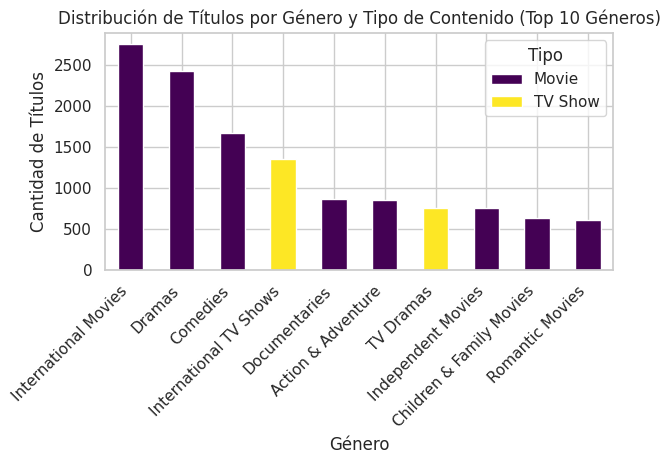

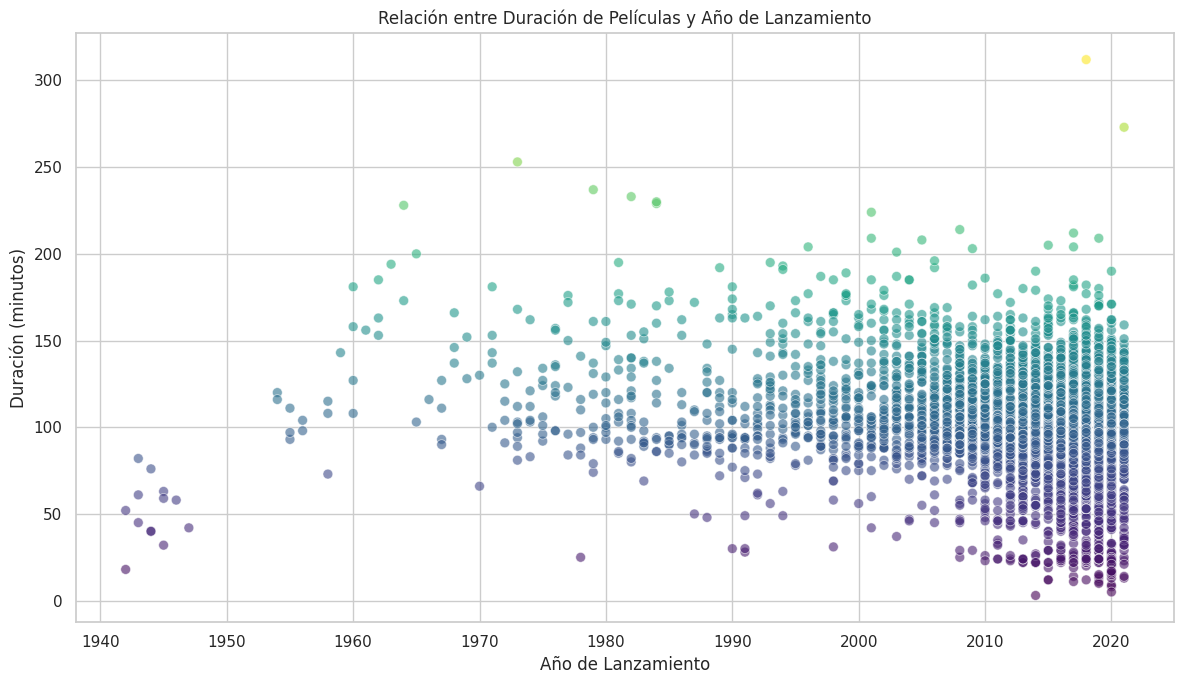

In [10]:
# 7. Top 10 países con más producciones
# Limpiar y contar países (puede haber múltiples países por título)
country_counts = df['country'].dropna().str.split(',').explode().str.strip().value_counts().nlargest(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=country_counts.index, y=country_counts.values, hue=country_counts.index, palette='plasma', legend=False)
plt.title('Top 10 Países con Más Producciones en Netflix')
plt.xlabel('País')
plt.ylabel('Cantidad de Producciones')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ¿Qué países dominan el catálogo? ¿Sorprende la distribución o es esperada?
# Respuesta: Estados Unidos domina abrumadoramente el catálogo, seguido por India y el Reino Unido.
# Esta distribución es esperada dado el tamaño de la industria cinematográfica y televisiva de EE. UU. e India,
# y el impacto global del contenido británico.

# 8. Películas vs Series según género
# Expandir los géneros para contar individualmente
genre_df = df.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in')

# Contar películas y series por género
genre_type_counts = genre_df.groupby(['listed_in', 'type']).size().unstack(fill_value=0)

# Seleccionar los géneros más comunes para una mejor visualización
top_genres = genre_df['listed_in'].value_counts().nlargest(10).index
genre_type_counts_filtered = genre_type_counts.loc[top_genres]

plt.figure(figsize=(14, 8))
genre_type_counts_filtered.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Distribución de Títulos por Género y Tipo de Contenido (Top 10 Géneros)')
plt.xlabel('Género')
plt.ylabel('Cantidad de Títulos')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo')
plt.tight_layout()
plt.show()

# ¿Existen géneros más asociados a películas o a series?
# Respuesta: Géneros como 'Dramas', 'Comedies' e 'International Movies' tienen una cantidad significativa tanto de películas como de series.
# Sin embargo, 'Documentaries' está fuertemente asociado con películas, mientras que 'International TV Shows' y 'TV Dramas'
# son obviamente exclusivos de series, mostrando una clara especialización por tipo de contenido.

# 9. Relación entre duración y año de lanzamiento
# Filtrar solo películas (ya tenemos movies_df con 'duration_minutes')
# Asegurarse de usar release_year y duration_minutes de las películas

plt.figure(figsize=(12, 7))
sns.scatterplot(data=movies_df, x='release_year', y='duration_minutes', alpha=0.6, s=50, hue='duration_minutes', palette='viridis', legend=False)
plt.title('Relación entre Duración de Películas y Año de Lanzamiento')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Duración (minutos)')
plt.grid(True)
plt.tight_layout()
plt.show()

# ¿Han cambiado los estándares de duración de las películas con el tiempo? ¿Se ven outliers interesantes?
# Respuesta: En general, no parece haber un cambio drástico en los estándares de duración de las películas a lo largo del tiempo,
# manteniéndose la mayoría entre 80 y 140 minutos. Sin embargo, se observan algunos outliers,
# especialmente películas con duraciones muy cortas (por debajo de 60 minutos) o muy largas (más de 180-200 minutos),
# que podrían ser documentales, especiales o producciones experimentales.

## ⭐ Desafío Final

* Encuentra las combinaciones más frecuentes de **género + rating** y represéntalas en un **heatmap o gráfico de burbujas**.
* Pregunta guía: ¿Qué géneros están más dirigidos a un público adulto? ¿Y cuáles a público familiar o infantil?

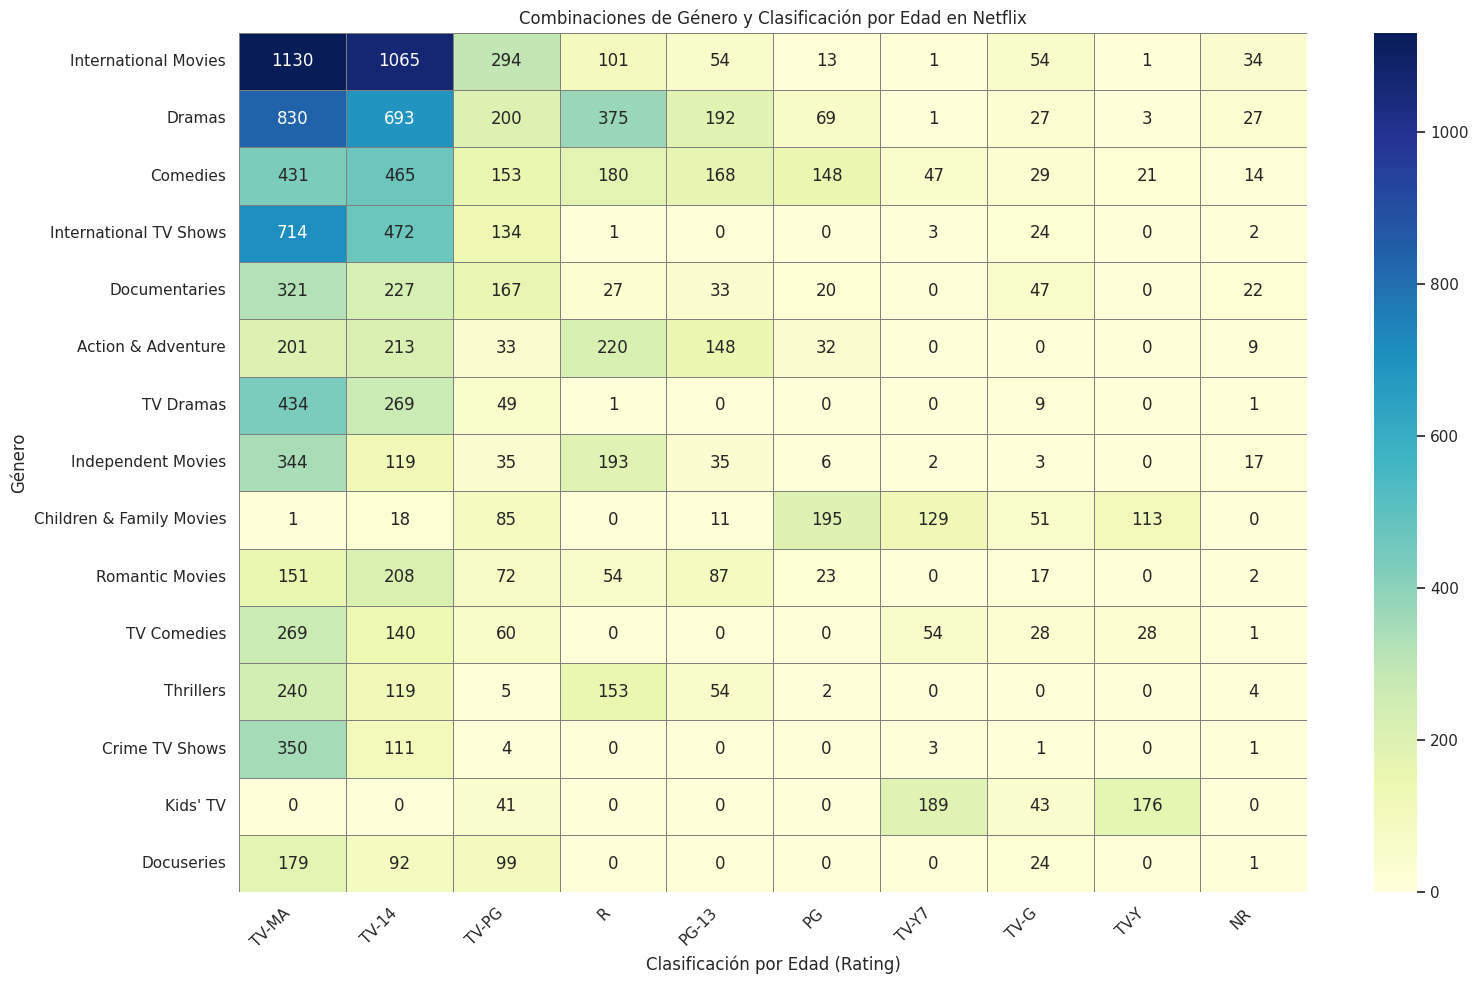

In [11]:
# Desafío Final: Combinaciones más frecuentes de género + rating

# 1. Preparar los datos
# Expandir los géneros (cada título puede tener múltiples géneros)
genre_rating_df = df.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in')

# Eliminar nulos en 'rating' y 'listed_in' para este análisis
genre_rating_df = genre_rating_df.dropna(subset=['rating', 'listed_in'])

# Contar las combinaciones de género y rating
genre_rating_counts = genre_rating_df.groupby(['listed_in', 'rating']).size().unstack(fill_value=0)

# Seleccionar los top N géneros para una mejor visualización del heatmap
top_genres_challenge = genre_rating_df['listed_in'].value_counts().nlargest(15).index
genre_rating_counts_filtered = genre_rating_counts.loc[top_genres_challenge]

# Seleccionar las clasificaciones por edad más comunes para una mejor visualización
top_ratings_challenge = genre_rating_df['rating'].value_counts().nlargest(10).index
genre_rating_counts_filtered = genre_rating_counts_filtered[top_ratings_challenge]

# 2. Crear el Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(genre_rating_counts_filtered, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5, linecolor='gray')
plt.title('Combinaciones de Género y Clasificación por Edad en Netflix')
plt.xlabel('Clasificación por Edad (Rating)')
plt.ylabel('Género')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Pregunta guía: ¿Qué géneros están más dirigidos a un público adulto? ¿Y cuáles a público familiar o infantil?
# Respuesta:
# Público adulto: Géneros como 'Dramas', 'International Movies', 'Thrillers', 'Action & Adventure', 'Independent Movies'
# y 'Comedies' muestran una alta frecuencia en clasificaciones como 'TV-MA' (audiencia madura) y 'TV-14' (mayores de 14 años).
# Esto indica que una gran parte del contenido de Netflix está dirigido a audiencias más maduras.
# Público familiar o infantil: Géneros como 'Children & Family Movies' y 'Kids' TV' se asocian fuertemente con
# clasificaciones como 'TV-Y' (todas las edades), 'TV-G' (audiencia general), 'TV-PG' (guía parental) y 'PG' (guía parental).
# Esto es esperable y confirma que Netflix también ofrece contenido específico para estas audiencias, aunque en menor proporción general.